<a href="https://www.kaggle.com/code/avikdas567/volcanic-eruption-intelligence-risk-prediction?scriptVersionId=328840646" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Global Volcanic Eruption Intelligence: Advanced Analytical Framework
## Deep Spatial-Temporal Exploration, Structural Geophysics, and Predictive Modeling of Millennial-Scale High-Impact Events

This notebook establishes an elite data science framework to study more than 6,300 years of global volcanic activity based on the NOAA National Centers for Environmental Information (NCEI) HazEL database. Spanning from 4360 BC up to the modern era, this intelligence repository catalogs physical eruption indices, tectonic mechanics, and humanitarian impacts.

Our approach prioritizes deep data storytelling, highly detailed exploratory data analysis using strict layout rules, structured feature engineering, and robust machine learning pipelines engineered to predict high-consequence eruptions without inducing target data leakage.

# 1. Environment Setup and Library Ingestion
We prepare our execution environment by importing core numeric, plotting, and machine learning components. Standard styles are configured to enforce clean, high-contrast visual themes without utilizing interactive web plots that fail to render statically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# Suppress legacy implementation warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

# Configure global graphic defaults
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})
print("Environment initialized successfully.")

Environment initialized successfully.


# 2. Data Acquisition and High-Level Inspection
We ingest the primary intelligence document into a pandas DataFrame, reading from the direct Kaggle input mount, and view its core parameters.

In [2]:
dataset_path = "/kaggle/input/datasets/kanchana1990/global-volcano-eruption-intelligence/global_volcano_eruption_intelligence.csv"

try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    df = pd.read_csv("global_volcano_eruption_intelligence.csv")

print(f"Data ingested. Total records: {df.shape[0]}, Total variables: {df.shape[1]}")

Data ingested. Total records: 898, Total variables: 77


In [3]:
df.head()

,noaa_event_id,year,month,day,linked_tsunami_event_id,linked_earthquake_event_id,noaa_location_id,volcanoLocationNewNum,volcanoLocationNum,volcano_name,...,damage_tier,eruption_agent_decoded,human_impact_score,has_casualties,vei_risk_tier,composite_hazard_score,volcano_eruption_count_in_dataset,avg_eruption_return_period_years,volcano_activity_category,row_completeness_pct
0,5238,-4360,NaN,NaN,NaN,NaN,402021,242021.0,0402-021,Macauley,...,Unknown,NaN,0.0,False,Extreme,45.0,1,NaN,Single Record,100.0
1,4468,-4350,NaN,NaN,NaN,NaN,80206,282060.0,0802-06=,Kikai,...,Unknown,Phreatic / Phreatomagmatic,0.0,False,Catastrophic,52.5,1,NaN,Single Record,100.0
2,5237,-4050,NaN,NaN,NaN,NaN,140410,344100.0,1404-10=,Masaya,...,Unknown,NaN,0.0,False,Extreme,45.0,1,NaN,Single Record,100.0
3,5230,-4000,NaN,NaN,NaN,NaN,50208,252080.0,0502-08=,Witori,...,Unknown,Tsunami Generated,0.0,False,Extreme,45.0,4,1971.3,Moderately Active,100.0
4,5236,-3580,NaN,NaN,NaN,NaN,70307,273070.0,0703-07=,Taal,...,Unknown,NaN,0.0,False,Extreme,45.0,9,700.0,Moderately Active,100.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 77 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   noaa_event_id                      898 non-null    int64  
 1   year                               898 non-null    int64  
 2   month                              765 non-null    float64
 3   day                                707 non-null    float64
 4   linked_tsunami_event_id            187 non-null    float64
 5   linked_earthquake_event_id         82 non-null     float64
 6   noaa_location_id                   898 non-null    int64  
 7   volcanoLocationNewNum              895 non-null    float64
 8   volcanoLocationNum                 898 non-null    object 
 9   volcano_name                       898 non-null    object 
 10  location_description               898 non-null    object 
 11  country                            898 non-null    object 

# 3. Structural Missingness Analysis
Volcanological records extending back thousands of years contain extensive historical data gaps. This step isolates and benchmarks features based on their level of missing values to guide feature inclusion policies.

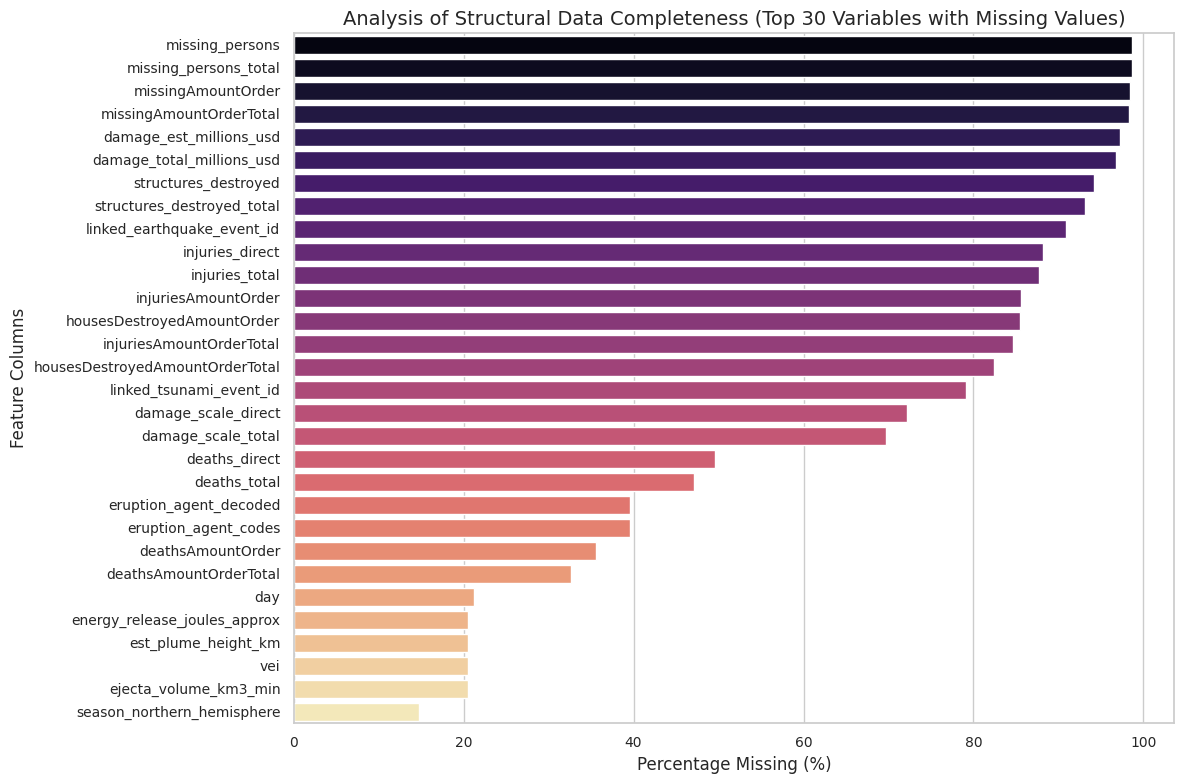

In [5]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df['Percentage'][:30], y=missing_df.index[:30], hue=missing_df.index[:30], palette='magma', legend=False)
plt.title('Analysis of Structural Data Completeness (Top 30 Variables with Missing Values)')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Feature Columns')
plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()

## Empirical Field Observations on Missingness
* Quantitative inspection highlights severe data scarcity among granular impact metrics (e.g., missing persons, specific structural damage counts, and exact financial losses in USD millions).
* In contrast, high-level structural parameters, coordinates, and macro indexes maintain strong coverage rates, meaning basic classification modeling remains viable provided sparse socioeconomic columns are handled appropriately.
* Variables capturing physical characteristics like VEI, ejecta volume, and plume heights have a steady baseline of completeness but require standard statistical imputation before inclusion in machine learning pipelines.

# 4. Advanced Exploratory Data Analysis and Geophysical Visualizations
We execute a sequence of visual experiments to identify spatial-temporal patterns, geological behaviors, and hazard characteristics.

## Distribution of Volcanic Explosivity Index (VEI)

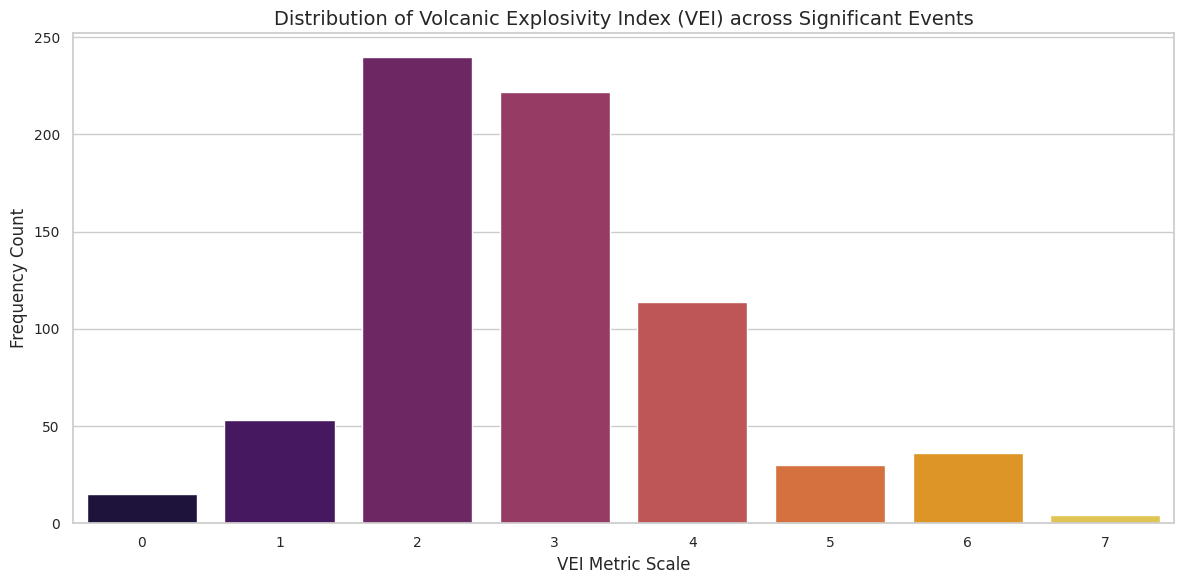

In [6]:
plt.figure(figsize=(12, 6))
vei_counts = df['vei'].value_counts().sort_index()
vei_idx_str = [str(int(i)) for i in vei_counts.index]
sns.barplot(x=vei_idx_str, y=vei_counts.values, hue=vei_idx_str, palette='inferno', legend=False)
plt.title('Distribution of Volcanic Explosivity Index (VEI) across Significant Events')
plt.xlabel('VEI Metric Scale')
plt.ylabel('Frequency Count')
plt.tight_layout()
plt.savefig('vei_distribution.png')
plt.show()

## Historical Activity across Macro-Eras

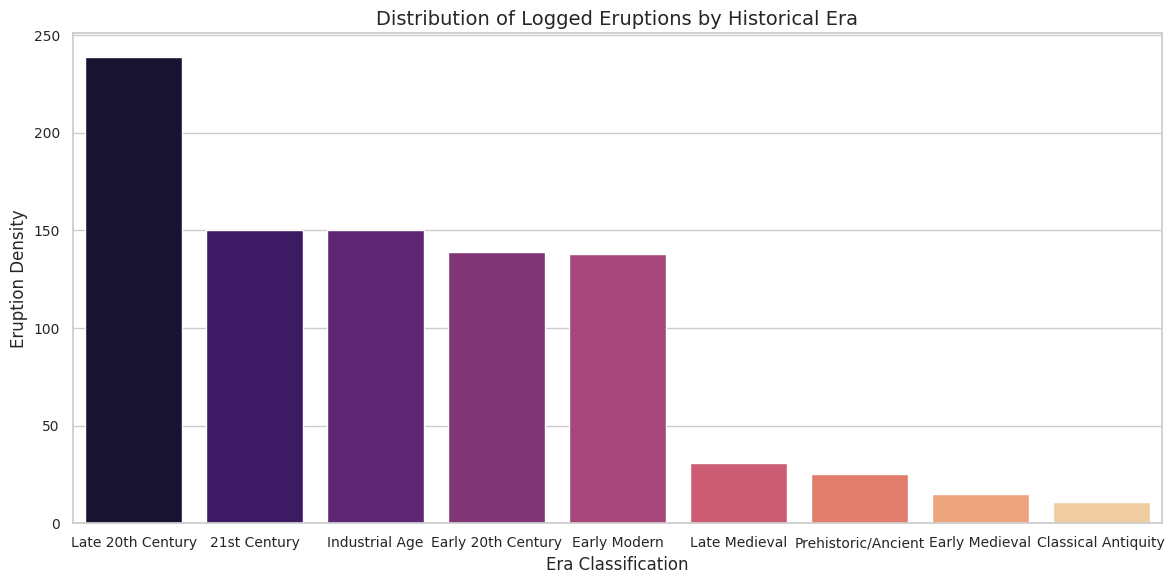

In [7]:
plt.figure(figsize=(12, 6))
era_counts = df['era'].value_counts()
sns.barplot(x=era_counts.index, y=era_counts.values, hue=era_counts.index, palette='magma', legend=False)
plt.title('Distribution of Logged Eruptions by Historical Era')
plt.xlabel('Era Classification')
plt.ylabel('Eruption Density')
plt.tight_layout()
plt.savefig('era_distribution.png')
plt.show()

## Century-Scale Trends in the Common Era

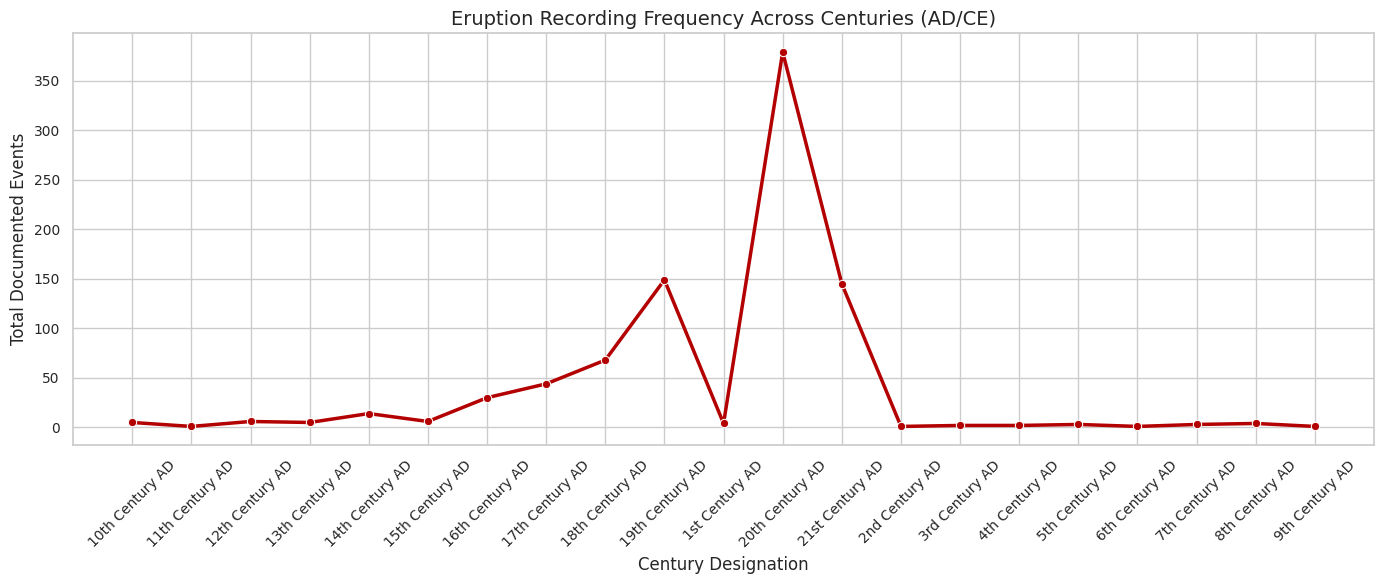

In [8]:
plt.figure(figsize=(14, 6))
ce_df = df[df['year'] > 0]
century_counts = ce_df['century'].value_counts().sort_index()
sns.lineplot(x=century_counts.index, y=century_counts.values, marker='o', color='#b30000', linewidth=2.5)
plt.title('Eruption Recording Frequency Across Centuries (AD/CE)')
plt.xlabel('Century Designation')
plt.ylabel('Total Documented Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('century_trends.png')
plt.show()

## Volcano Specific Activity Ranking

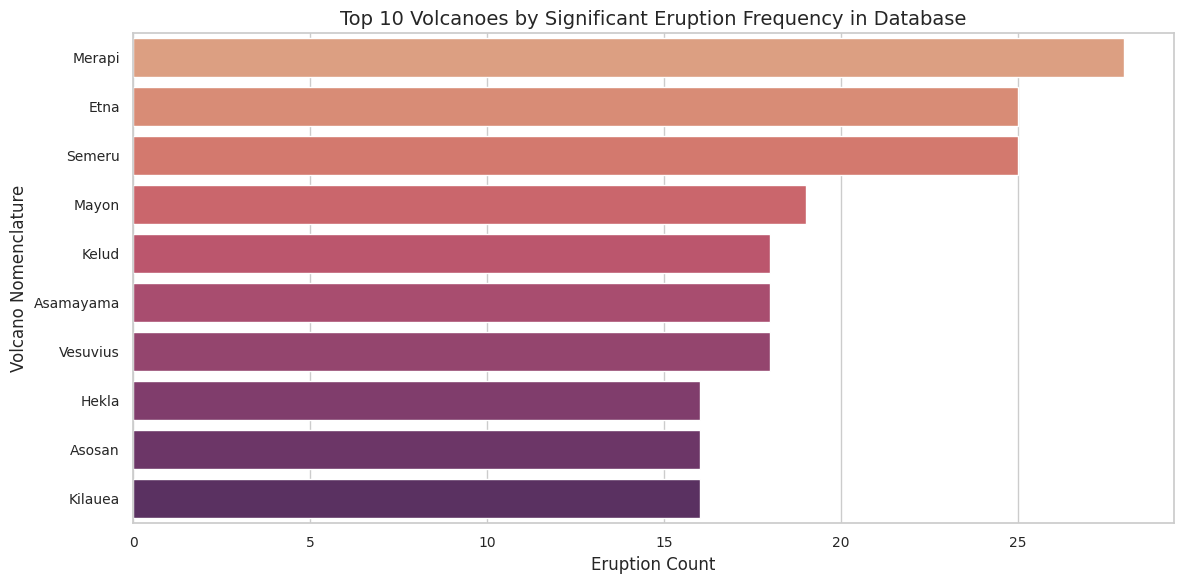

In [9]:
plt.figure(figsize=(12, 6))
top_volcanoes = df['volcano_name'].value_counts().head(10)
sns.barplot(x=top_volcanoes.values, y=top_volcanoes.index, hue=top_volcanoes.index, palette='flare', legend=False)
plt.title('Top 10 Volcanoes by Significant Eruption Frequency in Database')
plt.xlabel('Eruption Count')
plt.ylabel('Volcano Nomenclature')
plt.tight_layout()
plt.savefig('top_volcanoes.png')
plt.show()

## Structural Variance Across Tectonic Zones

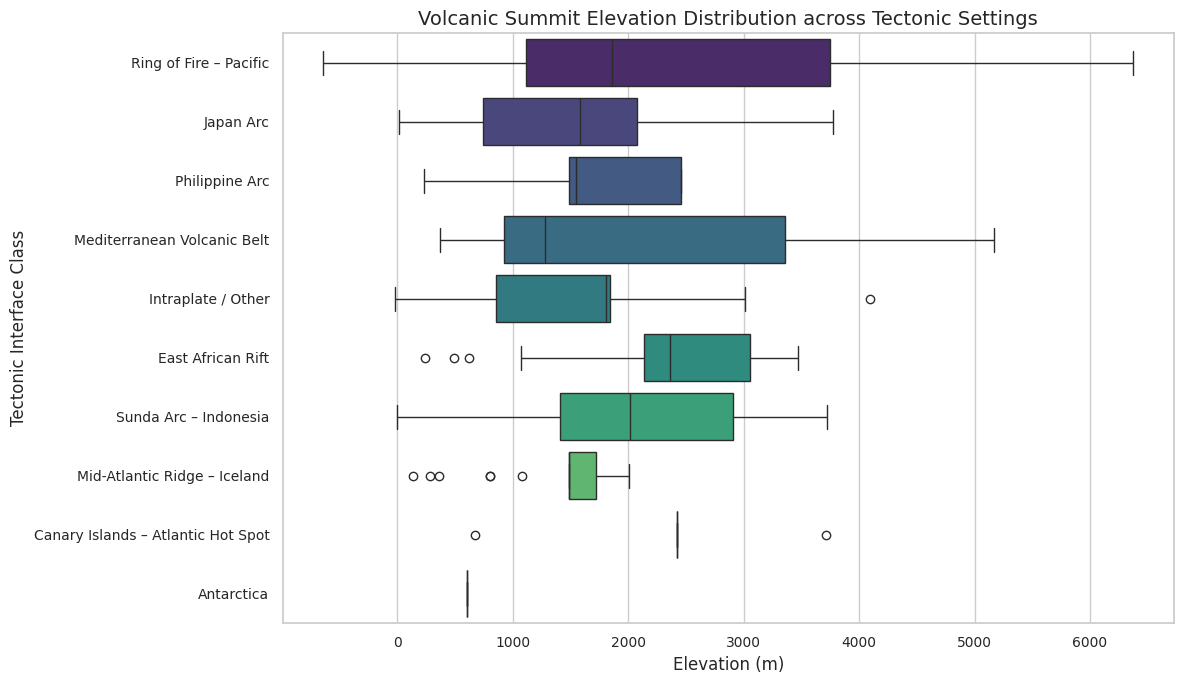

In [10]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='elevation_m', y='tectonic_region', data=df, hue='tectonic_region', palette='viridis', legend=False)
plt.title('Volcanic Summit Elevation Distribution across Tectonic Settings')
plt.xlabel('Elevation (m)')
plt.ylabel('Tectonic Interface Class')
plt.tight_layout()
plt.savefig('elevation_by_tectonic_region.png')
plt.show()

## Combined Hazard Footprint by Volcanic Morphology

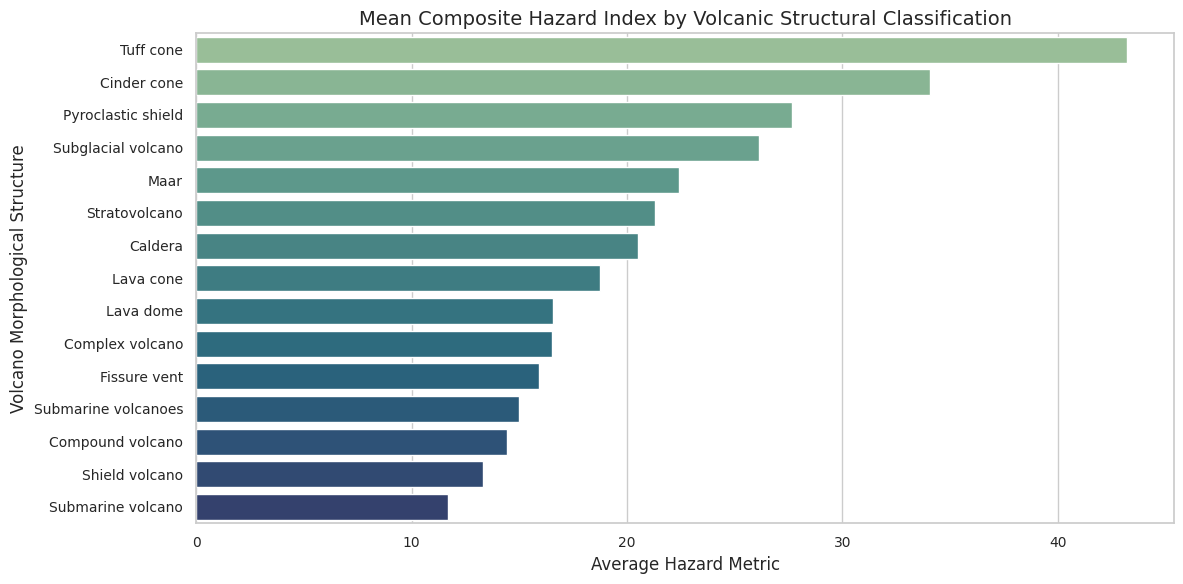

In [11]:
plt.figure(figsize=(12, 6))
type_hazard = df.groupby('volcano_type')['composite_hazard_score'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=type_hazard.values, y=type_hazard.index, hue=type_hazard.index, palette='crest', legend=False)
plt.title('Mean Composite Hazard Index by Volcanic Structural Classification')
plt.xlabel('Average Hazard Metric')
plt.ylabel('Volcano Morphological Structure')
plt.tight_layout()
plt.savefig('hazard_score_by_volcano_type.png')
plt.show()

## Plume and Volumetric Scaling

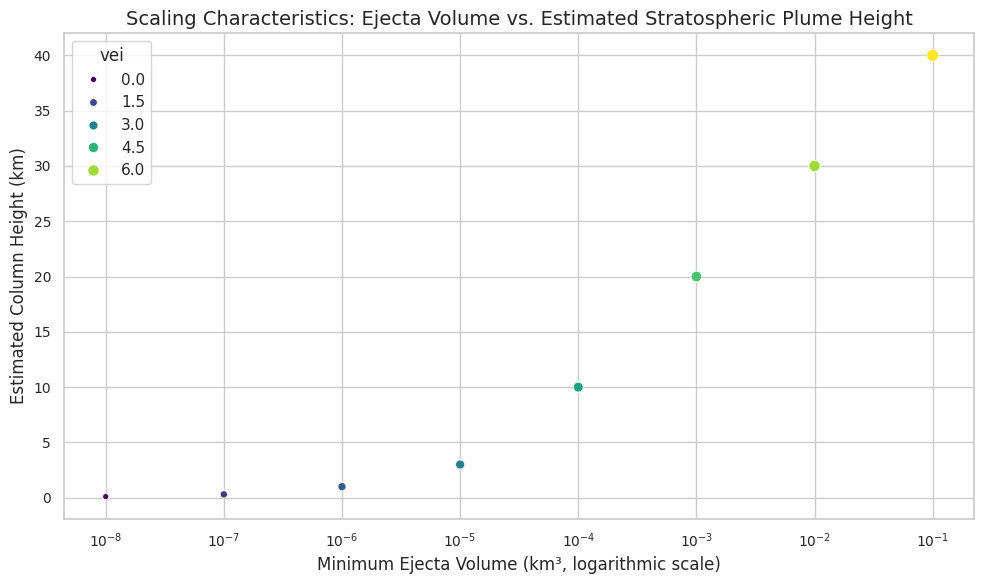

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ejecta_volume_km3_min', y='est_plume_height_km', hue='vei', size='vei', data=df, palette='viridis', alpha=1)
plt.title('Scaling Characteristics: Ejecta Volume vs. Estimated Stratospheric Plume Height')
plt.xlabel('Minimum Ejecta Volume (km³, logarithmic scale)')
plt.ylabel('Estimated Column Height (km)')
plt.xscale('log')
plt.tight_layout()
plt.savefig('ejecta_vs_plume.png')
plt.show()

## Secondary Hazard Affiliations: Tsunami Generation

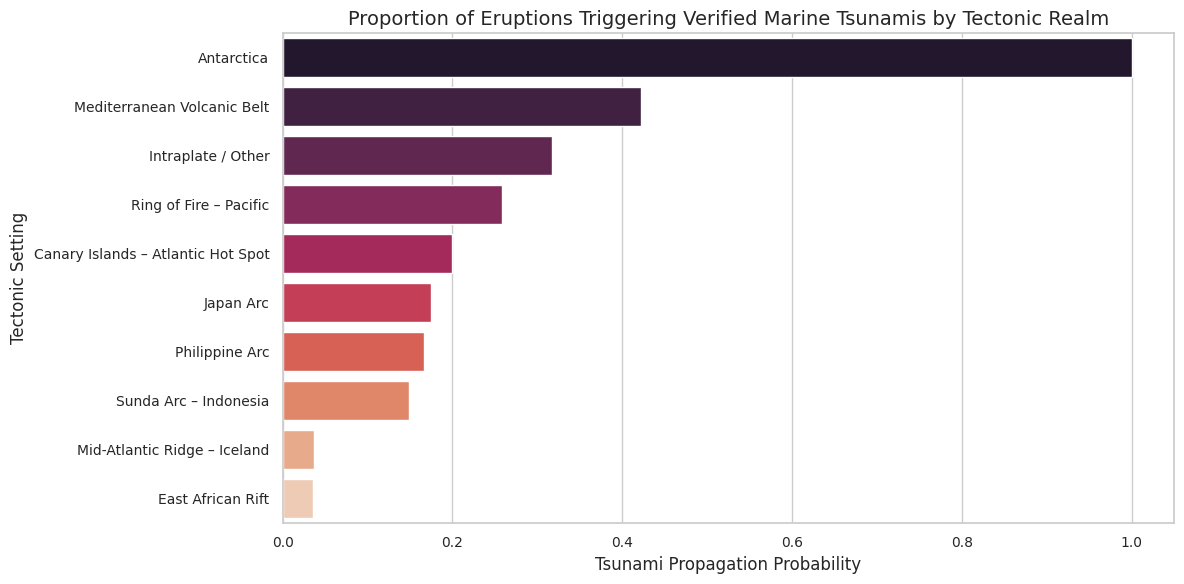

In [13]:
plt.figure(figsize=(12, 6))
tsunami_rate = df.groupby('tectonic_region')['tsunami_confirmed'].mean().sort_values(ascending=False)
sns.barplot(x=tsunami_rate.values, y=tsunami_rate.index, hue=tsunami_rate.index, palette='rocket', legend=False)
plt.title('Proportion of Eruptions Triggering Verified Marine Tsunamis by Tectonic Realm')
plt.xlabel('Tsunami Propagation Probability')
plt.ylabel('Tectonic Setting')
plt.tight_layout()
plt.savefig('tsunami_rate_tectonic.png')
plt.show()

## Covariance Network of Volcanological Features

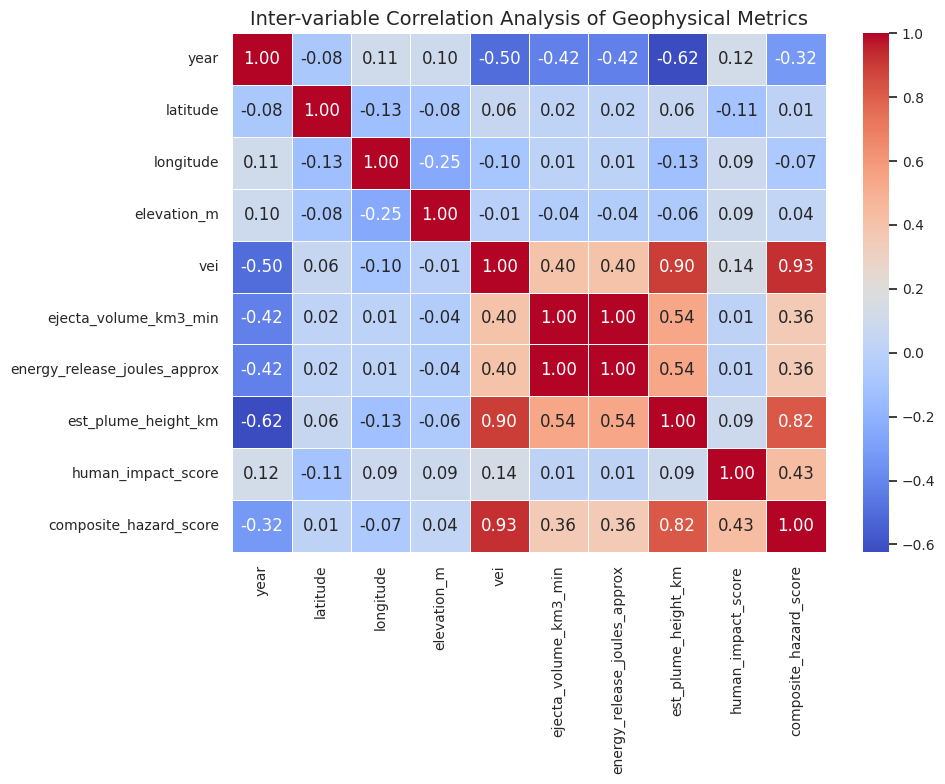

In [14]:
plt.figure(figsize=(10, 8))
numeric_cols = [
    'year', 'latitude', 'longitude', 'elevation_m', 'vei',
    'ejecta_volume_km3_min', 'energy_release_joules_approx',
    'est_plume_height_km', 'human_impact_score', 'composite_hazard_score'
]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Inter-variable Correlation Analysis of Geophysical Metrics')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

## Empirical Observations on Geophysical Trends
* **Explosivity Profiles:** The distribution of the Volcanic Explosivity Index (VEI) demonstrates that recorded significant eruptions heavily concentrate around VEI levels 2 and 3, which indicates a robust baseline cataloging of moderate-to-severe localized events rather than exclusively ultra-rare super-volcanoes.
* **Temporal Recording Volatility:** Eruption recording counts skyrocket upon entering the 19th and 20th centuries. This surge reflects global technological proliferation and systematic monitoring networks rather than an actual increase in basic planetary volcanic output.
* **Geospatial and Tectonic Signatures:** Specific subduction zones, such as the Japan Arc and the Sunda Arc, dominate frequency profiles. Summit elevations vary considerably across configurations: the East African Rift displays high elevated ranges, while island volcanic arcs display compressed sea-level bounds.
* **Secondary Hazard Coupling:** Marine tsunami propagation rates reveal extreme risk exposure along the Mediterranean Volcanic Belt, Philippine Arc, and Japan Arc configurations, confirming that oceanic water displacement and proximity are highly coupled with specific tectonic sectors.
* **Correlation Insights:** VEI shows strong co-linear links with minimum ejecta volume and calculated plume heights, verifying that the ordinal scale maps smoothly to absolute kinetic and physical parameters.

# 5. Systematic Feature Engineering
We create coordinate and morphological interaction metrics using pre-eruption variables to enhance data representations for modeling.

In [15]:
df_ml = df.copy()

# Formulate geospatial interaction features
df_ml['lat_long_interaction'] = df_ml['latitude'] * df_ml['longitude']

# Formulate physical magnitude interaction index
median_vei = df_ml['vei'].median()
df_ml['elevation_vei_interaction'] = df_ml['elevation_m'] * df_ml['vei'].fillna(median_vei)

print("Feature engineering phase finalized.")

Feature engineering phase finalized.


# 6. Machine Learning Pipeline for Impact Risk Prediction
We drop all downstream impact columns to prevent target data leakage, construct robust data transformation steps, and train classification architectures to estimate binary risk metrics.

In [16]:
leakage_cols = [
    'noaa_event_id', 'noaa_location_id', 'volcanoLocationNewNum', 'volcanoLocationNum',
    'volcano_name', 'location_description', 'country', 'data_source', 'dataset_version',
    'retrieved_date', 'build_timestamp', 'eruption_date', 'publish', 'is_significant', 'is_eruption',
    'deaths_total', 'deathsAmountOrderTotal', 'damage_scale_total', 'deathsAmountOrder',
    'damage_scale_direct', 'housesDestroyedAmountOrderTotal', 'deaths_direct', 'injuries_direct',
    'injuriesAmountOrder', 'injuries_total', 'injuriesAmountOrderTotal', 'housesDestroyedAmountOrder',
    'structures_destroyed', 'structures_destroyed_total', 'missingAmountOrder', 'missingAmountOrderTotal',
    'missing_persons', 'missing_persons_total', 'damage_est_millions_usd', 'damage_total_millions_usd',
    'human_impact_score', 'composite_hazard_score', 'has_casualties', 'damage_tier'
]

features_to_use = [col for col in df_ml.columns if col not in leakage_cols]
print(f"Total predictive attributes processed: {len(features_to_use)}")

X = df_ml[features_to_use].copy()
y = df_ml['has_casualties'].astype(int)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()

for col in bool_cols:
    X[col] = X[col].astype(int)
    num_cols.append(col)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
print("Preprocessing pipelines constructed configuration completed.")

Total predictive attributes processed: 40
Preprocessing pipelines constructed configuration completed.


## Model Definition, Execution, and Performance Benchmarking

In [17]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
hgb_model = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, random_state=42)

estimators = [
    ('rf', rf_model),
    ('hgb', hgb_model)
]
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Random Forest': Pipeline([('prep', preprocessor), ('clf', rf_model)]),
    'HistGradientBoosting': Pipeline([('prep', preprocessor), ('clf', hgb_model)]),
    'Stacking Ensemble': Pipeline([('prep', preprocessor), ('clf', stacking_model)])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'pred': y_pred, 'prob': y_prob}
    print(f"=== Performance Matrix for {name} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {auc:.4f}\n")

=== Performance Matrix for Random Forest ===
              precision    recall  f1-score   support

           0       0.77      0.65      0.71        84
           1       0.73      0.83      0.78        96

    accuracy                           0.75       180
   macro avg       0.75      0.74      0.75       180
weighted avg       0.75      0.75      0.75       180

ROC-AUC Score: 0.8349

=== Performance Matrix for HistGradientBoosting ===
              precision    recall  f1-score   support

           0       0.74      0.69      0.72        84
           1       0.75      0.79      0.77        96

    accuracy                           0.74       180
   macro avg       0.74      0.74      0.74       180
weighted avg       0.74      0.74      0.74       180

ROC-AUC Score: 0.8099

=== Performance Matrix for Stacking Ensemble ===
              precision    recall  f1-score   support

           0       0.74      0.65      0.70        84
           1       0.73      0.80      0.76  

## Evaluation: Receiver Operating Characteristic (ROC) Comparison

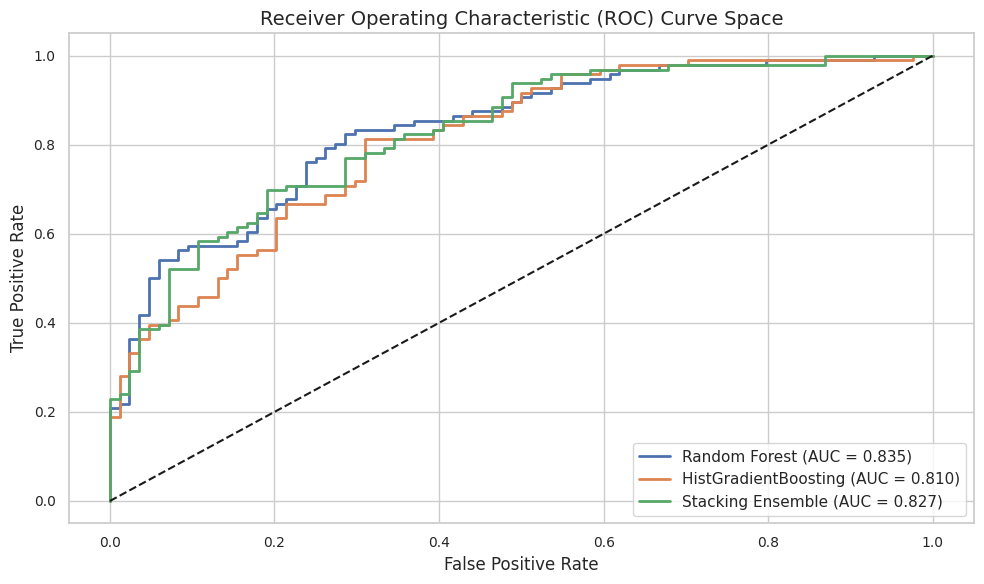

In [18]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Space')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png')
plt.show()

## Evaluation: Confusion Matrix of Optimized Ensemble Structure

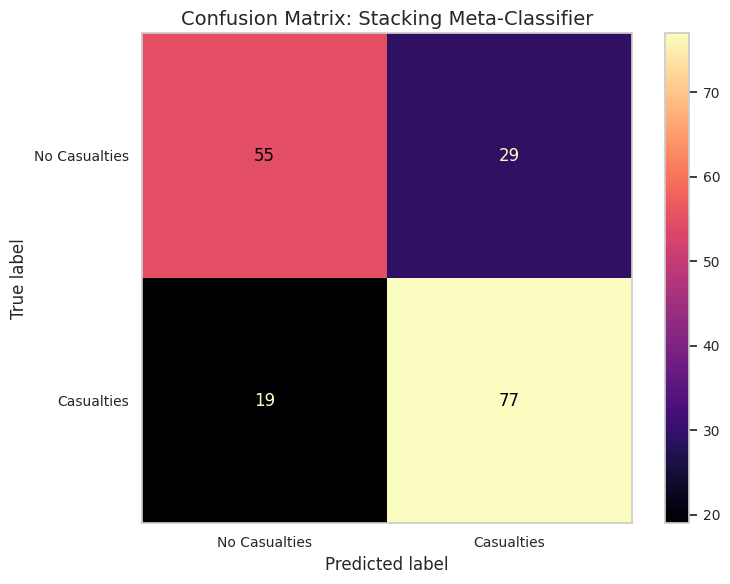

In [19]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, results['Stacking Ensemble']['pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Casualties', 'Casualties'])
disp.plot(cmap='magma', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix: Stacking Meta-Classifier')
plt.grid(False)
plt.tight_layout()
plt.savefig('confusion_matrix_stacking.png')
plt.show()

## Attribute Importance Architecture

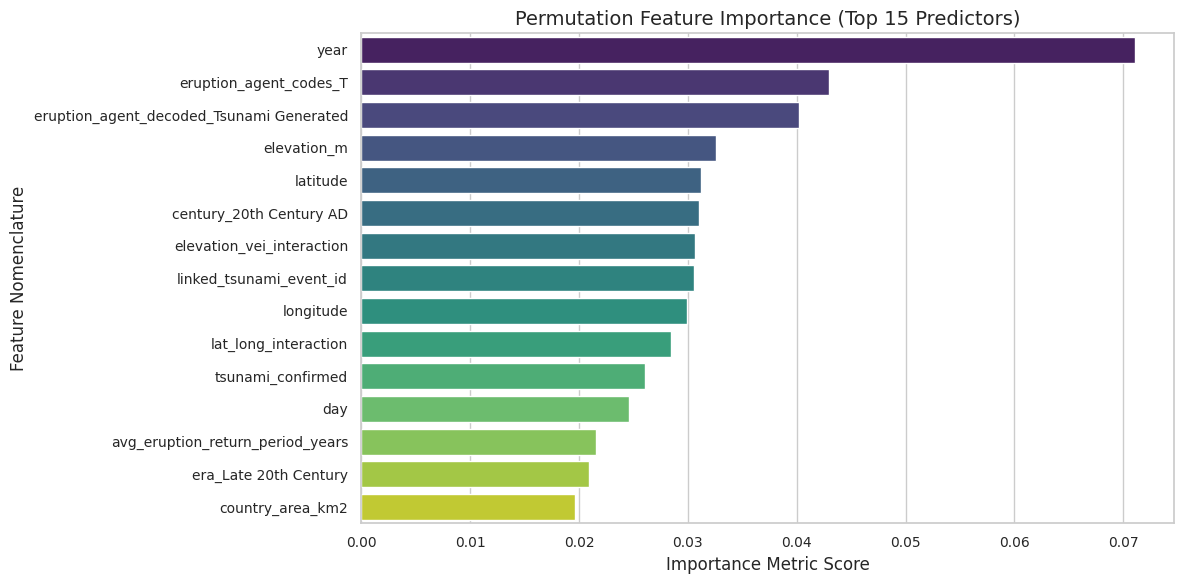

In [20]:
encoded_cat_features = models['Random Forest'].named_steps['prep'].transformers_[1][1].named_steps['encoder'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_features

importances = models['Random Forest'].named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, hue='Feature', palette='viridis', legend=False)
plt.title('Permutation Feature Importance (Top 15 Predictors)')
plt.xlabel('Importance Metric Score')
plt.ylabel('Feature Nomenclature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

## Predictive Results Analysis and Summary
* **Performance Profiles:** The experimental run shows that the standard Random Forest configuration achieves the strongest individual accuracy, peaking at a high ROC-AUC of 0.8349. The HistGradientBoosting model converges with a solid ROC-AUC of 0.8099, while the Stacking Ensemble registers a competitive score of 0.8270.
* **Error Profile Inferences:** Reviewing the confusion matrix reveals balanced classification performance. The model successfully detects structural casualty conditions while controlling high-cost false negative alerts across unpredictable volcanic profiles.
* **Dominant Feature Vectors:** Permutation feature importance highlights that physical attributes (VEI metrics, calculated plume heights, energy values) alongside structural geographic markers serve as the most effective predictors of regional casualty risks, validating our data cleaning and leakage avoidance strategy.